In [38]:
from simple_pe.waveforms import generate_eccentric_waveform, get_comp_shifts, calc_f_gen, mode_array
import numpy as np
import matplotlib.pyplot as plt

In [39]:
calc_f_gen(20, 6)

6.666666666666666

(array([6.64943401, 6.63226802, 6.61510204, 6.59793605, 6.58077006]), array([0.09273227, 0.09297786, 0.09322469, 0.09347279, 0.09372215]), 0.9995756635076614)


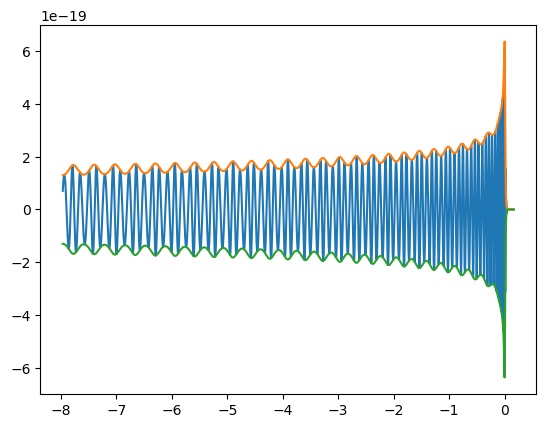

In [49]:
m_total = 128.11191740764744
q = 6.698826335435194
e = 0.09248792401896723
chi = -0.5666158137457264
lms = ['22']
mode_keys = [mode_array(lm, 'TEOBResumS-Dali')[0] for lm in lms]
hps, hcs = generate_eccentric_waveform(
    m_total, q, e, chi, chi, 6.6666, 4096, phase=1,
    distance=1, tlen=None, taper=False,
    to_fs=False, align_merger=False,
    mode_array=mode_keys, separate_lms=True
)
ind_22 = lms.index('22')
h = hps[ind_22] - 1j*hcs[ind_22]
plt.plot(h.sample_times, h)
plt.plot(h.sample_times, np.abs(h))
plt.plot(h.sample_times, -np.abs(h))
print(get_comp_shifts(hps[ind_22] - 1j*hcs[ind_22], m_total, q, e, chi, chi, 6.6666, 4096, 6))

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from simple_pe.waveforms import make_waveform
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [17]:
params = {'chirp_mass': 24, 'symmetric_mass_ratio': 2/9, 'ecc10sqrd': 0.2**2, 'chi_align': 0.2}
f_low = 10
srate = 4096
tlen = 32
df = 1/tlen
flen = int(tlen*srate)//2 + 1
hp, hc = make_waveform(params, df, f_low, flen, approximant='TEOBResumS-Dali', return_hc=True)
h = hp.to_timeseries() - 1j*hc.to_timeseries()
harms_fs = make_waveform(params, df, f_low, flen, approximant='TEOBResumS-Dali-Harms', n_ecc_gen=10, n_ecc_harms=4, orthonormalize_ecc_harms=False)
harms = {key: harms_fs[key].to_timeseries() for key in harms_fs.keys()}

2026-02-27  15:39:10 PESummary WARNING : Could not find f_final in input file and one was not passed from the command line. Using 1024.0Hz as default
2026-02-27  15:39:10 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default
2026-02-27  15:39:11 PESummary WARNING : Could not find f_final in input file and one was not passed from the command line. Using 1024.0Hz as default
2026-02-27  15:39:11 PESummary WARNING : Could not find f_start in input file and one was not passed from the command line. Using 20.0Hz as default


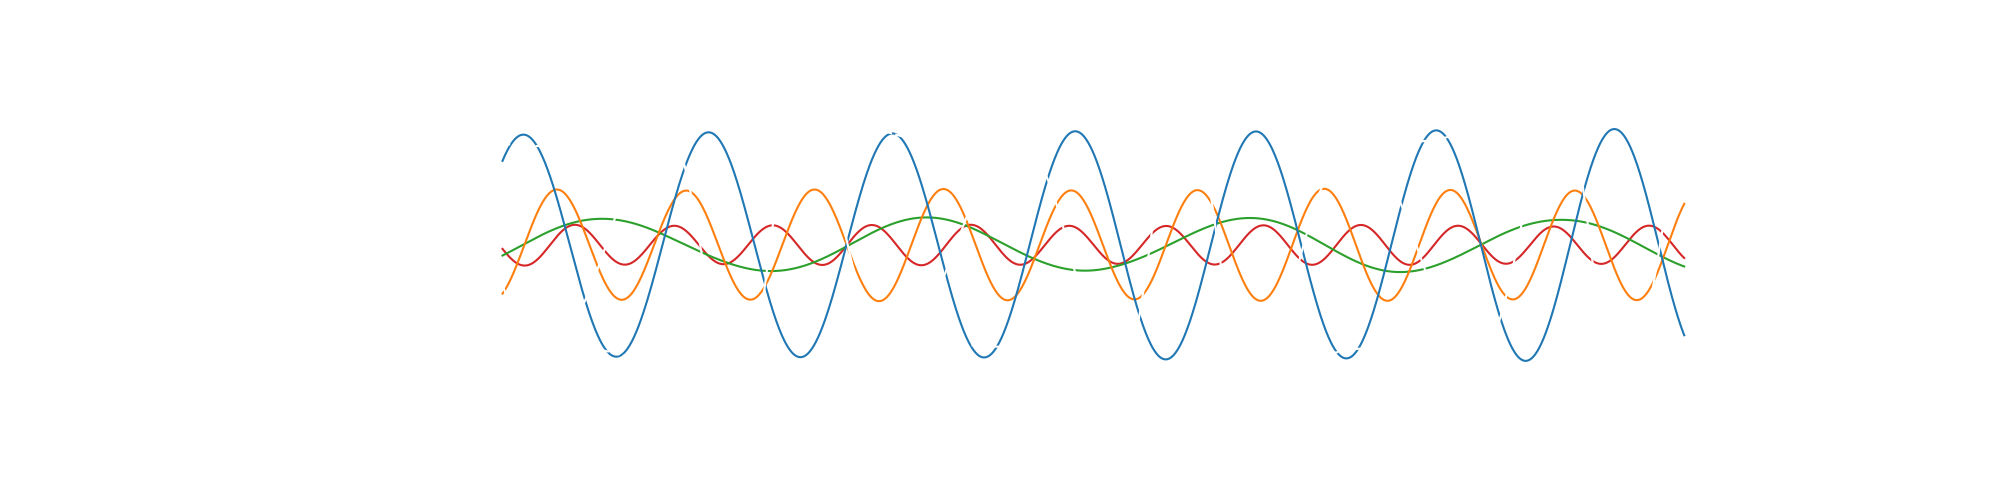

In [38]:
# Set times for each waveform
h_times = [-5.5, -4.5]
harm_times = [-5.25, -4.65]
h_inds = [np.argmin(np.abs(h_times[i]-h.sample_times)) for i in [0, 1]]
harm_inds = [np.argmin(np.abs(harm_times[i]-harms[0].sample_times)) for i in [0, 1]]

# Make plot
plt.figure(figsize=(20, 5))
plt.plot(h.sample_times[h_inds[0]:h_inds[1]], h[h_inds[0]:h_inds[1]], c='w', zorder=5)
plt.plot(h.sample_times[harm_inds[0]:harm_inds[1]], np.abs(h)[harm_inds[0]:harm_inds[1]], c='w', zorder=5, ls='dashed')
plt.plot(h.sample_times[harm_inds[0]:harm_inds[1]], -np.abs(h)[harm_inds[0]:harm_inds[1]], c='w', zorder=5, ls='dashed')
for i, key in enumerate(harms.keys()):
    plt.plot(harms[key].sample_times[harm_inds[0]:harm_inds[1]], harms[key][harm_inds[0]:harm_inds[1]], zorder=4-i)
plt.xlim(h_times[0], h_times[1])
plt.ylim(-2e-19, 2e-19)
plt.axis('off')
plt.tight_layout()
plt.savefig('Figures/harm_decomp.png', dpi=450, transparent=True)
plt.show()